In [ ]:
import torch
import random
import matplotlib.pyplot as plt

# Build Montecarlo Environment

In [ ]:
size = 10
states = size * size
rewards = torch.tensor([1,0])

num_actions = 4

In [ ]:
def step_function(state,action):
  row,col  = state//size,state%size
  action_move = [
      lambda row, col: (max(0,row-1), col), # up
      lambda row, col: (min(size-1,row+1), col), # down
      lambda row, col: (row, max(col-1,0)), # left
      lambda row, col: (row, min(col+1,size-1)) # right
  ]
  new_row, new_col = action_move[action](row,col)
  new_state = new_row * size + new_col
  return new_state
# state, state_col, state_row = step_function(4,3)

# TD(0) - STATE VALUE

In [ ]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [24,20,31]
size= 10
V = torch.zeros(size*size)
Q = torch.zeros(size*size, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9 # discount factor for future rewards --> to calcualte the return a time t in a specific episode
alpha = 0.6 # --> should be 1/N where N is the number of times the state has been visited (many visits) or the number of episodes the state appears in (first visit).
# practically it should be the "returns_count" variable
# using a constant alpha-step is convenient when the problem is non stationary. it gives more importance to new experience

terminal_state = 24
policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([0 if _ not in terminal_states else 1 for _ in range(states)])
state = initial_state
rewards

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])

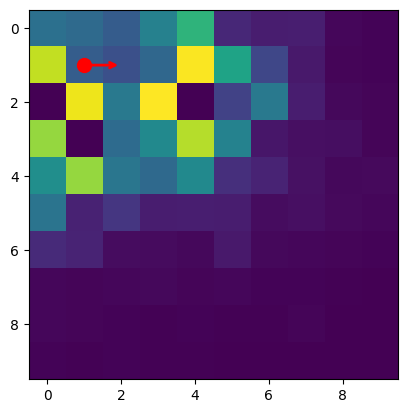

In [ ]:
#############################################
# EXECUTE MANY TIMES TO SEE THE EVOLUTION!! #
#############################################


# ----------- CONTROL V---------------

action = torch.multinomial(policy[state], 1)
current_state = state
new_state = step_function(state,action )
if new_state in terminal_states:
  V[state] = V[state]+ alpha *(rewards[new_state] - V[state] )
  state = initial_state
else:
  V[state] = V[state]+ alpha *(rewards[new_state] + discount_factor * V[new_state]- V[state] )
  state = new_state


# ----------- VIZ ---------------
fig,ax = plt.subplots(1,1)

current_row = current_state // size
current_col = current_state % size
ax.scatter(current_col, current_row, c='red', s=100, marker='o')


next_row = new_state // size
next_col = new_state % size


ax.annotate('', xy=(next_col, next_row), xytext=(current_col, current_row),
               arrowprops=dict(arrowstyle='->', lw=2, color='red'))

V_grid = V.view(size,size)

ax.imshow(V_grid)

In [ ]:
# ------------- ITERATIONS ---------------
for episode in range(episodes):
  for _ in range(max_step):
    action = torch.multinomial(policy[state], 1)
    new_state = step_function(state,action )
    if new_state in terminal_states:
      V[state] = V[state]+ alpha *(rewards[new_state] - V[state] )
      state = initial_state
    else:
      V[state] = V[state]+ alpha *(rewards[new_state] + discount_factor * V[new_state]- V[state] )
      state = new_state


# Q-LEARNING

In [ ]:
###########
# CONFIG  #
###########
######################################################
# change these values to see how the agent reacts!   #
######################################################
initial_state = 0
initial_action = 0
terminal_states = [24,20,31]
size= 10
V = torch.zeros(size*size)
Q = torch.zeros(size*size, num_actions)

episodes = 1000 # <-- see the evolution one update at a time, because montecarlo does the update one each episode
max_step = 100


discount_factor = 0.9
alpha = 0.6

terminal_state = 24
policy = torch.ones(size*size, 4) / 4
rewards = torch.tensor([0 if _ not in terminal_states else 1 for _ in range(states)])
state = initial_state
rewards

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0])

In [ ]:
# ----------- CONTROL Q ---------------

action = torch.multinomial(policy[state], 1)
new_state = step_function(state,action )
new_action = torch.multinomial(policy[new_state], 1)
if new_state in terminal_states:
  Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
  state = initial_state
  action = new_action
else:
  Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state, new_action]- Q[state, action] )
  state = new_state
  action = new_action




In [ ]:
# ------------- ITERATIONS ---------------
action = torch.multinomial(policy[state], 1)
for episode in range(episodes):
  for _ in range(max_step):
    new_state = step_function(state,action )
    new_action = torch.multinomial(policy[new_state], 1)
    if new_state in terminal_states:
      Q[state, action] = Q[state, action] + alpha * (rewards[new_state]- Q[state, action])
      state = initial_state
      action = torch.multinomial(policy[state], 1)
    else:
      Q[state, action] = Q[state, action]+ alpha *(rewards[new_state] + discount_factor * Q[new_state, new_action]- Q[state, action] )
      state = new_state
      action = new_action